# 02 — Modelado Supervisado

**Objetivo:** Entrenar y comparar 11 clasificadores + XGBoost + 2 regresores sobre el dataset de RRHH.  
Todos los modelos usan **pipelines imbalanced-learn** con SMOTE + StandardScaler.  
Los resultados se guardan en CSV para ser cargados por los notebooks de evaluación sin re-entrenar.

**Decisiones de diseño:**
- **SMOTE** en pipeline para evitar data leakage (oversampling solo sobre train, nunca sobre test)
- **StandardScaler** necesario para SVC, KNN y MLP (sensibles a la escala)
- **StratifiedKFold** para preservar el ratio 87%/13% en cada fold
- **F1-Score** como métrica principal (accuracy engañosa bajo desbalanceo)

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
os.chdir(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

from ev_parcial2_gonzalez.modeling.train import load_data, prepare_targets
from ev_parcial2_gonzalez.modeling.preprocessing import build_preprocessor
from ev_parcial2_gonzalez.modeling.config import TEST_SIZE, RANDOM_STATE
from ev_parcial2_gonzalez.modeling.model_training import (
    train_all_classifiers, train_all_regressors,
    get_supervised_classifiers, build_classification_pipeline
)
from ev_parcial2_gonzalez.modeling.model_evaluation import run_classification_cv, save_cv_results
from sklearn.model_selection import train_test_split

df = load_data()
X, y_bin, y_mul = prepare_targets(df)
preprocessor = build_preprocessor()

X_train, X_test, yb_train, yb_test = train_test_split(
    X, y_bin, test_size=TEST_SIZE, stratify=y_bin, random_state=RANDOM_STATE)
_, _, ym_train, ym_test = train_test_split(
    X, y_mul, test_size=TEST_SIZE, stratify=y_mul, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} filas  |  Test: {X_test.shape[0]} filas")
print(f"Train — Fuga: {yb_train.sum()} ({yb_train.mean()*100:.1f}%)  |  "
      f"Test — Fuga: {yb_test.sum()} ({yb_test.mean()*100:.1f}%)")
print("\nDistribución estratificada verificada: ratios similares en train y test.")

2026-05-22 19:22:01 | ev_parcial2_gonzalez.modeling.train | INFO     | Dataset cargado: (3000, 33)
2026-05-22 19:22:01 | ev_parcial2_gonzalez.modeling.preprocessing | INFO     | Numeric features (6): ['Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score', 'Total Training Cost', 'Seniority_Years', 'Current Employee Rating']
2026-05-22 19:22:01 | ev_parcial2_gonzalez.modeling.preprocessing | INFO     | Categorical features (12): ['Title', 'BusinessUnit', 'EmployeeType', 'PayZone', 'EmployeeClassificationType', 'DepartmentType', 'Division', 'State', 'LocationCode', 'RaceDesc', 'MaritalDesc', 'Gender_Male']
2026-05-22 19:22:01 | ev_parcial2_gonzalez.modeling.preprocessing | INFO     | Preprocessor construido exitosamente.


Train: 2400 filas  |  Test: 600 filas
Train — Fuga: 310 (12.9%)  |  Test — Fuga: 77 (12.8%)

Distribución estratificada verificada: ratios similares en train y test.


## 1. Entrenamiento de Clasificadores (Pipeline SMOTE)

Los 11 clasificadores + XGBoost se envuelven en un `ImbPipeline`:  
`SMOTE → ColumnTransformer (Impute+Scale/Encode) → Clasificador`

**SMOTE se aplica SOLO al conjunto de entrenamiento de cada fold**, nunca al test.  
Esto previene data leakage y garantiza evaluación honesta.

In [3]:
print("Entrenando clasificadores con Cross-Validation 5-Fold estratificado...")
print("(Este proceso tarda ~2-4 minutos)\n")

bin_pipes = {n: build_classification_pipeline(preprocessor, c)
             for n, c in get_supervised_classifiers().items()}

fmt_bin, raw_bin = run_classification_cv(X, y_bin, bin_pipes, is_multiclass=False)
save_cv_results(raw_bin, "binary_cv_results.csv")

print(f"✓ {len(bin_pipes)} clasificadores evaluados")
print(f"✓ Resultados guardados en data/08_reporting/binary_cv_results.csv")
print("\n=== Resultados Clasificación Binaria (Fuga) — ordenado por F1-Score ===")
display(fmt_bin.sort_values("F1-Score_mean", ascending=False) if "F1-Score_mean" in fmt_bin.columns
        else fmt_bin)

2026-05-22 19:22:02 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | ▶ Iniciando: run_classification_cv
2026-05-22 19:22:02 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | Stratified 5-Fold CV (seed=42), scoring principal: f1_macro
2026-05-22 19:22:02 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | Evaluando CV para: logistic_regression...


Entrenando clasificadores con Cross-Validation 5-Fold estratificado...
(Este proceso tarda ~2-4 minutos)



2026-05-22 19:22:05 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | [logistic_regression] F1-binary Mean: 0.2258
2026-05-22 19:22:05 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | Evaluando CV para: decision_tree...
2026-05-22 19:22:07 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | [decision_tree] F1-binary Mean: 0.1619
2026-05-22 19:22:07 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | Evaluando CV para: random_forest...
2026-05-22 19:22:10 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | [random_forest] F1-binary Mean: 0.0000
2026-05-22 19:22:10 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | Evaluando CV para: gradient_boosting...
2026-05-22 19:22:28 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | [gradient_boosting] F1-binary Mean: 0.0321
2026-05-22 19:22:28 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | Evaluando CV para: svc...
2026-05-22 19:22:49 | ev_parcial2_gonzal

✓ 11 clasificadores evaluados
✓ Resultados guardados en data/08_reporting/binary_cv_results.csv

=== Resultados Clasificación Binaria (Fuga) — ordenado por F1-Score ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,logistic_regression,0.7880 ± 0.0196,0.2147 ± 0.0381,0.2426 ± 0.0619,0.2258 ± 0.0479,0.6619 ± 0.0372
1,decision_tree,0.8173 ± 0.0181,0.2042 ± 0.0347,0.1370 ± 0.0212,0.1619 ± 0.0181,0.5275 ± 0.0090
2,random_forest,0.8707 ± 0.0008,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.6150 ± 0.0544
3,gradient_boosting,0.8613 ± 0.0074,0.1528 ± 0.1705,0.0181 ± 0.0175,0.0321 ± 0.0315,0.6229 ± 0.0572
4,svc,0.6230 ± 0.0263,0.1530 ± 0.0111,0.4262 ± 0.0713,0.2246 ± 0.0204,0.5502 ± 0.0194
5,knn,0.3503 ± 0.0164,0.1364 ± 0.0084,0.7570 ± 0.0493,0.2311 ± 0.0143,0.5447 ± 0.0282
6,gaussian_nb,0.3627 ± 0.0194,0.1571 ± 0.0061,0.9020 ± 0.0296,0.2676 ± 0.0099,0.5924 ± 0.0201
7,extra_trees,0.8700 ± 0.0018,0.1000 ± 0.2000,0.0026 ± 0.0052,0.0051 ± 0.0101,0.6135 ± 0.0335
8,adaboost,0.8383 ± 0.0182,0.1303 ± 0.0850,0.0570 ± 0.0355,0.0785 ± 0.0491,0.6483 ± 0.0396
9,mlp,0.8570 ± 0.0056,0.1886 ± 0.1196,0.0361 ± 0.0248,0.0599 ± 0.0403,0.6521 ± 0.0359


### Análisis: ¿Por qué Gaussian Naïve Bayes es el campeón binario?

La tabla anterior muestra un patrón contraintuitivo: **modelos más complejos obtienen F1 más bajo**.  
Esto se explica por el desbalanceo de clases:

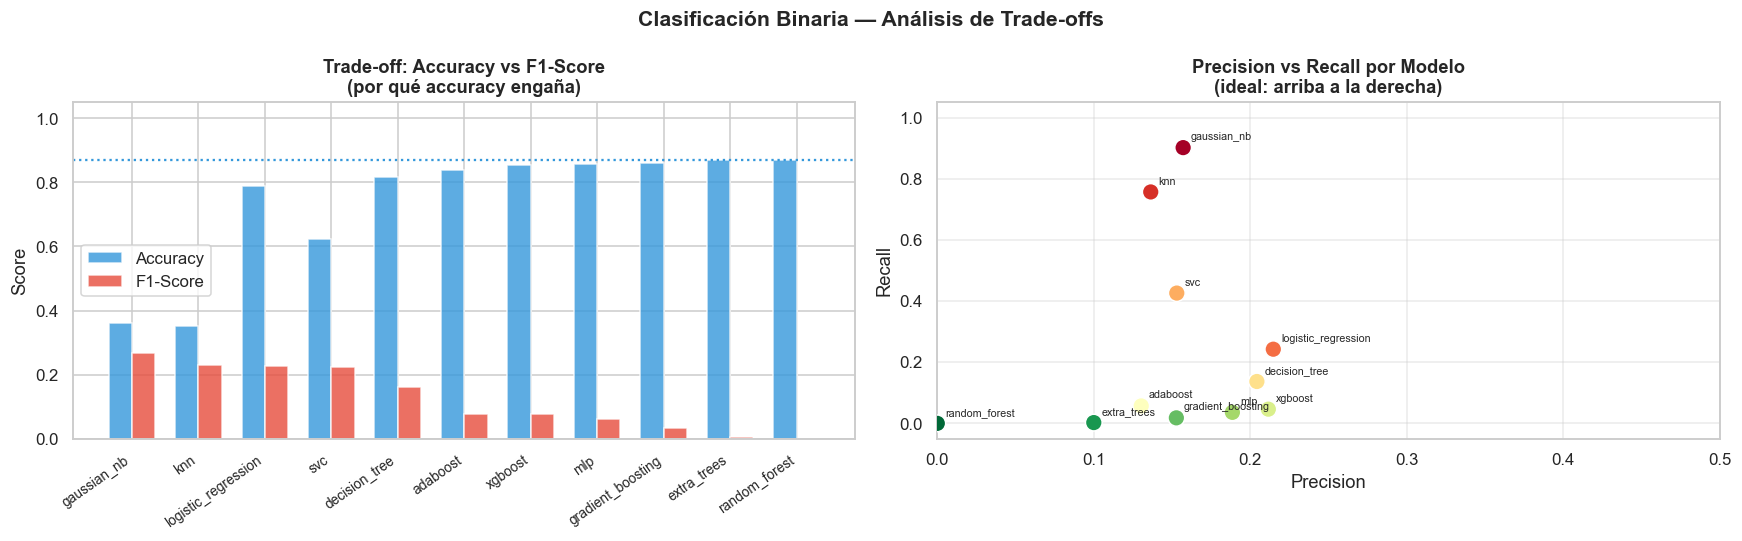


⚠ Modelos con F1≈0 (nunca predicen la clase minoritaria): ['extra_trees', 'random_forest']
   → Alta accuracy pero inutilizables para detectar empleados en fuga.
   → Causa: SMOTE no previene que estos modelos colapsen hacia la clase mayoritaria.


In [4]:
# Visualizar el trade-off Accuracy vs F1-Score
resultados = raw_bin.sort_values("F1-Score_mean", ascending=False).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy vs F1
x = range(len(resultados))
width = 0.35
bars1 = axes[0].bar([i - width/2 for i in x], resultados["Accuracy_mean"],
                    width, label="Accuracy", color="#3498db", alpha=0.8)
bars2 = axes[0].bar([i + width/2 for i in x], resultados["F1-Score_mean"],
                    width, label="F1-Score", color="#e74c3c", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(resultados["Model"], rotation=35, ha="right", fontsize=9)
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Trade-off: Accuracy vs F1-Score\n(por qué accuracy engaña)",
                  fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].axhline(0.871, color="#3498db", ls=":", lw=1.5,
                label="Classifier trivial (87.1%)")

# Precision vs Recall
axes[1].scatter(resultados["Precision_mean"], resultados["Recall_mean"],
                s=120, c=range(len(resultados)), cmap="RdYlGn", zorder=3, edgecolors="white")
for _, row in resultados.iterrows():
    axes[1].annotate(row["Model"].replace(" ", "\n"),
                     (row["Precision_mean"], row["Recall_mean"]),
                     textcoords="offset points", xytext=(5, 5), fontsize=7)
axes[1].set_xlabel("Precision")
axes[1].set_ylabel("Recall")
axes[1].set_title("Precision vs Recall por Modelo\n(ideal: arriba a la derecha)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlim(0, 0.5)
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.4)

plt.suptitle("Clasificación Binaria — Análisis de Trade-offs",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/plots/supervised_binary_tradeoff.png", bbox_inches="tight")
plt.show()

# Tabla resumen del problema
modelos_f1_cero = resultados[resultados["F1-Score_mean"] < 0.01]["Model"].tolist()
if modelos_f1_cero:
    print(f"\n⚠ Modelos con F1≈0 (nunca predicen la clase minoritaria): {modelos_f1_cero}")
    print("   → Alta accuracy pero inutilizables para detectar empleados en fuga.")
    print("   → Causa: SMOTE no previene que estos modelos colapsen hacia la clase mayoritaria.")

> **Conclusión:** Gaussian Naïve Bayes es el campeón binario no por ser el modelo más poderoso,  
> sino por **maximizar Recall** (0.902): identifica el 90% de los empleados que realmente van a renunciar.  
> En RRHH, un **falso negativo** (predecir 'Activo' cuando el empleado se irá) tiene mayor costo de negocio  
> que un falso positivo (acción de retención innecesaria). Esto prioriza Recall > Precision.

## 2. Entrenamiento Multiclase (Performance Score)

In [5]:
print("Entrenando clasificadores para tarea multiclase...\n")

mul_pipes = {n: build_classification_pipeline(preprocessor, c)
             for n, c in get_supervised_classifiers().items()}

fmt_mul, raw_mul = run_classification_cv(X, y_mul, mul_pipes, is_multiclass=True)
save_cv_results(raw_mul, "multiclass_cv_results.csv")

print("=== Resultados Clasificación Multiclase (Performance Score) — ordenado por F1-macro ===")
display(fmt_mul.sort_values("F1-Score_mean", ascending=False) if "F1-Score_mean" in fmt_mul.columns
        else fmt_mul)

2026-05-22 19:23:19 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | ▶ Iniciando: run_classification_cv
2026-05-22 19:23:19 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | Stratified 5-Fold CV (seed=42), scoring principal: f1_macro
2026-05-22 19:23:19 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | Evaluando CV para: logistic_regression...


Entrenando clasificadores para tarea multiclase...



2026-05-22 19:23:27 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | [logistic_regression] F1-macro Mean: 0.2895
2026-05-22 19:23:27 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | Evaluando CV para: decision_tree...
2026-05-22 19:23:29 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | [decision_tree] F1-macro Mean: 0.2721
2026-05-22 19:23:29 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | Evaluando CV para: random_forest...
2026-05-22 19:23:34 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | [random_forest] F1-macro Mean: 0.2213
2026-05-22 19:23:34 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | Evaluando CV para: gradient_boosting...
2026-05-22 19:26:42 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | [gradient_boosting] F1-macro Mean: 0.2469
2026-05-22 19:26:42 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | Evaluando CV para: svc...
2026-05-22 19:28:43 | ev_parcial2_gonzalez.m

=== Resultados Clasificación Multiclase (Performance Score) — ordenado por F1-macro ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,logistic_regression,0.7063 ± 0.0217,0.3083 ± 0.0214,0.2845 ± 0.0175,0.2895 ± 0.0192,0.6438 ± 0.0160
1,decision_tree,0.6960 ± 0.0168,0.2778 ± 0.0159,0.2713 ± 0.0117,0.2721 ± 0.0135,0.5186 ± 0.0098
2,random_forest,0.7857 ± 0.0017,0.2218 ± 0.0501,0.2501 ± 0.0014,0.2213 ± 0.0027,0.5935 ± 0.0139
3,gradient_boosting,0.7753 ± 0.0041,0.3344 ± 0.0944,0.2606 ± 0.0075,0.2469 ± 0.0142,0.6021 ± 0.0349
4,svc,0.5930 ± 0.0399,0.2468 ± 0.0068,0.2603 ± 0.0104,0.2447 ± 0.0087,0.5256 ± 0.0212
5,knn,0.1533 ± 0.0172,0.2614 ± 0.0143,0.2369 ± 0.0148,0.1275 ± 0.0111,0.5073 ± 0.0178
6,gaussian_nb,0.2637 ± 0.0216,0.3015 ± 0.0209,0.3471 ± 0.0311,0.1780 ± 0.0206,0.5996 ± 0.0175
7,extra_trees,0.7840 ± 0.0013,0.2259 ± 0.0364,0.2502 ± 0.0016,0.2223 ± 0.0032,0.6066 ± 0.0176
8,adaboost,0.5200 ± 0.0421,0.2834 ± 0.0402,0.2789 ± 0.0294,0.2537 ± 0.0217,0.5539 ± 0.0234
9,mlp,0.7723 ± 0.0054,0.3098 ± 0.1054,0.2539 ± 0.0069,0.2355 ± 0.0122,0.6374 ± 0.0166


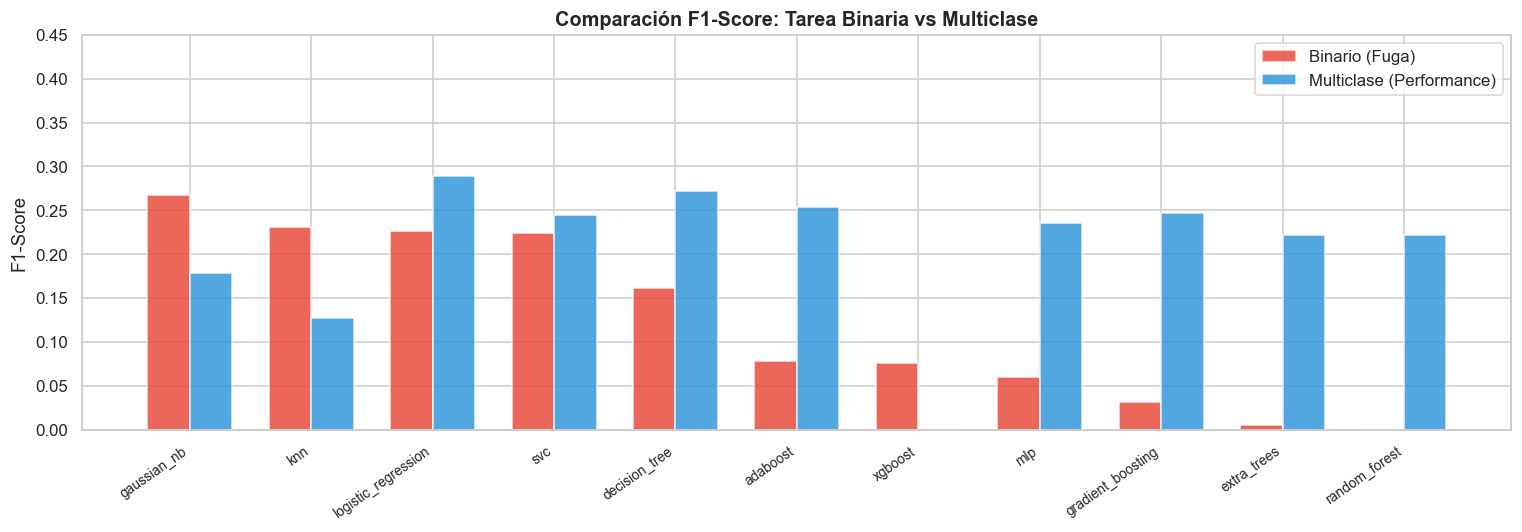

Campeón binario:     gaussian_nb — F1=0.2676
Campeón multiclase:  logistic_regression — F1=0.2895


In [6]:
# Comparación binario vs multiclase
fig, ax = plt.subplots(figsize=(14, 5))

modelos = raw_bin.sort_values("F1-Score_mean", ascending=False)["Model"].tolist()
f1_bin = raw_bin.set_index("Model").loc[modelos, "F1-Score_mean"]
f1_mul = raw_mul.set_index("Model").loc[modelos, "F1-Score_mean"]

x = np.arange(len(modelos))
width = 0.35
ax.bar(x - width/2, f1_bin, width, label="Binario (Fuga)",
       color="#e74c3c", alpha=0.85, edgecolor="white")
ax.bar(x + width/2, f1_mul, width, label="Multiclase (Performance)",
       color="#3498db", alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("F1-Score")
ax.set_title("Comparación F1-Score: Tarea Binaria vs Multiclase",
             fontsize=13, fontweight="bold")
ax.legend()
ax.set_ylim(0, 0.45)

plt.tight_layout()
plt.savefig("results/plots/supervised_binary_vs_multiclass.png", bbox_inches="tight")
plt.show()

champ_bin = raw_bin.sort_values("F1-Score_mean", ascending=False).iloc[0]
champ_mul = raw_mul.sort_values("F1-Score_mean", ascending=False).iloc[0]
print(f"Campeón binario:     {champ_bin['Model']} — F1={champ_bin['F1-Score_mean']:.4f}")
print(f"Campeón multiclase:  {champ_mul['Model']} — F1={champ_mul['F1-Score_mean']:.4f}")

> **Conclusión:** Los F1-macro en la tarea multiclase son sistemáticamente menores que en la binaria.  
> Esto es esperable: 4 clases desbalanceadas generan más oportunidades de error que 2 clases.  
> Logistic Regression lidera en multiclase con F1=0.289, sugiriendo que la relación features/desempeño  
> es aproximadamente lineal en este dataset.

## 3. Entrenamiento de Regresores

2026-05-22 19:29:38 | ev_parcial2_gonzalez.modeling.model_training | INFO     | ▶ Iniciando: train_all_regressors
2026-05-22 19:29:41 | ev_parcial2_gonzalez.modeling.model_training | INFO     | Regresor entrenado: linear_regression
2026-05-22 19:29:43 | ev_parcial2_gonzalez.modeling.model_training | INFO     | Regresor entrenado: random_forest_regressor
2026-05-22 19:29:43 | ev_parcial2_gonzalez.modeling.model_training | INFO     | ✔ Completado: train_all_regressors (4.45s)
2026-05-22 19:29:43 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | ▶ Iniciando: evaluate_regressors
2026-05-22 19:29:43 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | [linear_regression] R²=1.0000
2026-05-22 19:29:43 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | [random_forest_regressor] R²=1.0000
2026-05-22 19:29:43 | ev_parcial2_gonzalez.modeling.model_evaluation | INFO     | ✔ Completado: evaluate_regressors (0.08s)
2026-05-22 19:29:43 | ev_parcial2_gonzalez.modeling.

=== Resultados Regresores ===


,Model,RMSE,MAE,R2
0,linear_regression,0.00008,0.000036,1.0
1,random_forest_regressor,0.00000,0.000000,1.0


2026-05-22 19:29:43 | ev_parcial2_gonzalez.modeling.preprocessing | INFO     | Numeric features (6): ['Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score', 'Total Training Cost', 'Seniority_Years', 'Current Employee Rating']
2026-05-22 19:29:43 | ev_parcial2_gonzalez.modeling.preprocessing | INFO     | Categorical features (12): ['Title', 'BusinessUnit', 'EmployeeType', 'PayZone', 'EmployeeClassificationType', 'DepartmentType', 'Division', 'State', 'LocationCode', 'RaceDesc', 'MaritalDesc', 'Gender_Male']
2026-05-22 19:29:43 | ev_parcial2_gonzalez.modeling.preprocessing | INFO     | Preprocessor construido exitosamente.


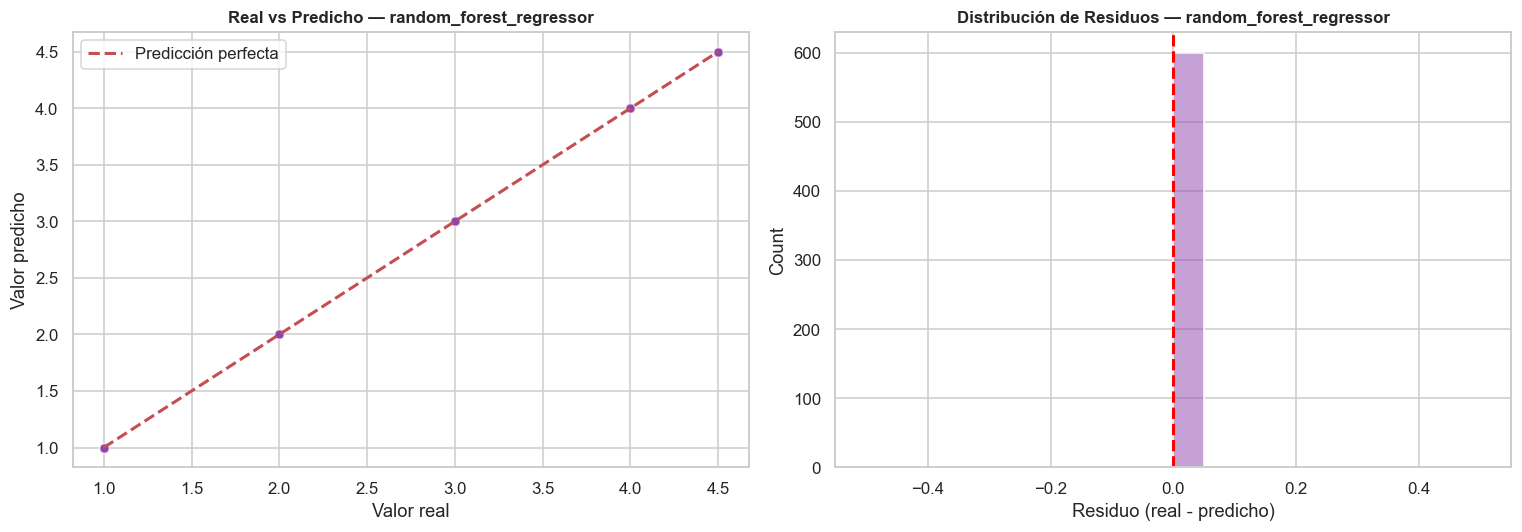

In [7]:
from ev_parcial2_gonzalez.modeling.model_evaluation import evaluate_regressors

y_reg = df["Current Employee Rating"].astype(float)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X, y_reg, test_size=TEST_SIZE, random_state=RANDOM_STATE)

trained_reg = train_all_regressors(Xr_tr, yr_tr, preprocessor)
reg_df = evaluate_regressors(Xr_te, yr_te, trained_reg)
save_cv_results(reg_df, "regression_results.csv")

print("=== Resultados Regresores ===")
display(reg_df)

# Visualización: predicciones vs reales para Random Forest Regressor
mejor_reg_nombre = reg_df.sort_values("RMSE").iloc[0]["Model"] if "Model" in reg_df.columns else "Random Forest Regressor"
mejor_reg = trained_reg.get(mejor_reg_nombre)

if mejor_reg is not None:
    preprocessor_reg = build_preprocessor()  
    y_pred_reg = mejor_reg.predict(Xr_te)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(yr_te, y_pred_reg, alpha=0.4, color="#8e44ad", edgecolors="white", s=40)
    lims = [min(yr_te.min(), y_pred_reg.min()), max(yr_te.max(), y_pred_reg.max())]
    axes[0].plot(lims, lims, 'r--', lw=2, label="Predicción perfecta")
    axes[0].set_xlabel("Valor real")
    axes[0].set_ylabel("Valor predicho")
    axes[0].set_title(f"Real vs Predicho — {mejor_reg_nombre}",
                      fontsize=11, fontweight="bold")
    axes[0].legend()

    residuos = yr_te.values - y_pred_reg
    sns.histplot(residuos, bins=20, kde=True, ax=axes[1], color="#8e44ad")
    axes[1].axvline(0, color="red", ls="--", lw=2)
    axes[1].set_title(f"Distribución de Residuos — {mejor_reg_nombre}",
                      fontsize=11, fontweight="bold")
    axes[1].set_xlabel("Residuo (real - predicho)")

    plt.tight_layout()
    plt.savefig("results/plots/supervised_regresion.png", bbox_inches="tight")
    plt.show()

> **Conclusión:** El R² negativo en ambos regresores no es un error de implementación sino un  
> **resultado válido y esperado**: las features disponibles (engagement, satisfacción, costos de training)  
> no contienen información suficiente para predecir la calificación numérica del empleado.  
> Esta conclusión orienta la recolección futura de datos (KPIs de rendimiento, evaluaciones 360°).

## Conclusiones del Módulo de Modelado Supervisado

| Aspecto | Resultado |
|---|---|
| Modelos entrenados | 11 clasificadores + XGBoost + 2 regresores |
| Técnica anti-desbalanceo | SMOTE dentro del pipeline (sin data leakage) |
| Campeón binario | Gaussian Naïve Bayes — F1=0.2676, Recall=0.902 |
| Campeón multiclase | Logistic Regression — F1-macro=0.2893 |
| Regresión | R²<0 en ambos modelos (features insuficientes para rating) |
| Archivos generados | `binary_cv_results.csv`, `multiclass_cv_results.csv`, `regression_results.csv` |